# 🤖 Naive Bayes Híbrido
## Clasificador para Variables Continuas y Binarias

---

**Materia:** Análisis Multivariado  
**Profesores:** Patricia Duarte Lezcano y Tomas Macrade  
**Fecha:** 18/6/2026

---

#### Alumnos
- Ivana Noelia Zurdo  
- Nicolas Barreto  
- Tomas Muino  
- Sebastian Sanchez Bentolila

![Logo de la UNAB](src/logo_unab.png)


## 📋 Contenido

1. [Introducción y contexto](#1.-Introducción-y-contexto)  
2. [Fundamentos matemáticos](#2.-Fundamentos-matemáticos)  
   - Teorema de Bayes  
   - Log-verosimilitud  
   - Bernoulli  
   - Gaussiana  
   - Suavizado de Laplace  
3. [Implementación](#3.-Implementación)  
4. [Tests y validación](#4.-Tests-y-validación)  
5. [Ejemplo de uso](#5.-Ejemplo-de-uso)  
6. [Visualizaciones](#6.-Visualizaciones)  
7. [Conclusiones](#7.-Conclusiones)


## 1. Introducción y contexto

**Naive Bayes** es un clasificador probabilístico basado en el *Teorema de Bayes*
que asume **independencia condicional** entre las features dado el valor de la clase.

A pesar de ser una suposición fuerte (y frecuentemente incorrecta en la práctica),
el modelo es sorprendentemente efectivo en muchos dominios y tiene varias ventajas:

| Ventaja | Descripción |
|---|---|
| ✅ Eficiencia | Entrenamiento y predicción en tiempo lineal |
| ✅ Escalabilidad | Funciona bien con pocas muestras |
| ✅ Interpretabilidad | Cada parámetro tiene significado probabilístico |
| ✅ Flexibilidad | Admite diferentes distribuciones por feature |

### ¿Qué implementamos?

Un **Naive Bayes híbrido** que detecta automáticamente el tipo de cada variable:

- 🔵 **Bernoulli** → para variables binarias (0/1)
- 🔴 **Gaussiana** → para variables continuas


## 2. Fundamentos matemáticos

### 2.1 Teorema de Bayes

La probabilidad posterior de la clase $C$ dado un vector de observaciones $\mathbf{x} = (x_1, x_2, \ldots, x_n)$ es:

$$P(C \mid \mathbf{x}) = \frac{P(\mathbf{x} \mid C) \cdot P(C)}{P(\mathbf{x})}$$

Donde:
- $P(C)$ es el **prior** de la clase (frecuencia relativa en el conjunto de entrenamiento)
- $P(\mathbf{x} \mid C)$ es la **verosimilitud** de los datos dado la clase
- $P(\mathbf{x})$ es la **evidencia** (constante para todas las clases)
- $P(C \mid \mathbf{x})$ es el **posterior** que queremos maximizar

Como $P(\mathbf{x})$ es constante, la regla de decisión se reduce a:

$$\hat{C} = \arg\max_{C} \; P(C) \cdot P(\mathbf{x} \mid C)$$


### 2.2 Suposición de independencia condicional

Naive Bayes asume que las features son **condicionalmente independientes** entre sí dado $C$:

$$P(\mathbf{x} \mid C) = \prod_{i=1}^{n} P(x_i \mid C)$$

Esto simplifica enormemente el cálculo, ya que solo necesitamos estimar distribuciones **univariadas** para cada feature.


### 2.3 Log-verosimilitud (estabilidad numérica)

El producto de probabilidades puede generar **underflow numérico** cuando $n$ es grande.
Para evitarlo, trabajamos en espacio logarítmico:

$$\log P(C \mid \mathbf{x}) \propto \log P(C) + \sum_{i=1}^{n} \log P(x_i \mid C)$$

La clase predicha es equivalente en ambos espacios porque el logaritmo es una función monótonamente creciente:

$$\hat{C} = \arg\max_{C} \left[ \log P(C) + \sum_{i=1}^{n} \log P(x_i \mid C) \right]$$


### 2.4 Distribución de Bernoulli

Para variables binarias $x_i \in \{0, 1\}$, la verosimilitud es:

$$P(x_i \mid C) = p_C^{x_i} \cdot (1 - p_C)^{1 - x_i}$$

Donde $p_C = P(x_i = 1 \mid C)$ se estima con **suavizado de Laplace** (para evitar probabilidades nulas):

$$\hat{p}_C = \frac{\text{count}(x_i = 1, C) + 1}{\text{count}(C) + 2}$$

El $+2$ en el denominador corresponde a agregar un pseudoconteo de 1 para cada valor posible (0 y 1).

En log-espacio:
$$\log P(x_i \mid C) = \begin{cases} \log(\hat{p}_C) & \text{si } x_i = 1 \\ \log(1 - \hat{p}_C) & \text{si } x_i = 0 \end{cases}$$


### 2.5 Distribución Gaussiana

Para variables continuas, asumimos que $x_i \mid C \sim \mathcal{N}(\mu_C,\, \sigma_C^2)$:

$$P(x_i \mid C) = \frac{1}{\sqrt{2\pi\sigma_C^2}} \exp\!\left(-\frac{(x_i - \mu_C)^2}{2\sigma_C^2}\right)$$

Los parámetros se estiman por **máxima verosimilitud** sobre las muestras de la clase $C$:

$$\hat{\mu}_C = \frac{1}{|\mathcal{D}_C|} \sum_{j \in \mathcal{D}_C} x_{ij} \qquad \hat{\sigma}_C^2 = \frac{1}{|\mathcal{D}_C|} \sum_{j \in \mathcal{D}_C} (x_{ij} - \hat{\mu}_C)^2$$

En log-espacio (aplicando logaritmo a la densidad):

$$\log P(x_i \mid C) = -\frac{1}{2}\log(2\pi\sigma_C^2) - \frac{(x_i - \mu_C)^2}{2\sigma_C^2}$$

> ⚠️ Si $\hat{\sigma}_C^2 = 0$ (todos los valores son iguales), se usa $\sigma^2 = 10^{-9}$ para evitar división por cero.


### 2.6 Normalización: predict_proba con log-sum-exp

Para obtener probabilidades calibradas en $[0,1]$ usamos el truco de **log-sum-exp**,
que es numéricamente estable:

$$P(C_k \mid \mathbf{x}) = \frac{e^{s_k}}{\sum_j e^{s_j}} = \exp\!\left(s_k - \log\sum_j e^{s_j}\right)$$

Donde $s_k = \log P(C_k) + \sum_i \log P(x_i \mid C_k)$ es el log-posterior no normalizado.


### Resumen visual: cadena de fórmulas

El siguiente diagrama muestra cómo se encadenan las transformaciones matemáticas desde el Teorema de Bayes hasta la predicción final.

<div style="text-align:center; margin: 1.5em 0;">
<svg width="680" viewBox="0 0 680 600" xmlns="http://www.w3.org/2000/svg" style="max-width:100%">
<defs>
<marker id="a2" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse">
  <path d="M2 1L8 5L2 9" fill="none" stroke="#888" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"/>
</marker>
</defs>
<!-- Paso 1: Bayes -->
<rect x="140" y="20" width="400" height="72" rx="12" fill="#EEEDFE" stroke="#7F77DD" stroke-width="0.8"/>
<text x="340" y="44" text-anchor="middle" font-size="14" font-weight="500" fill="#3C3489" dominant-baseline="central">1 · Teorema de Bayes</text>
<text x="340" y="70" text-anchor="middle" font-size="12" fill="#534AB7" dominant-baseline="central">P(C | x) = P(x | C) · P(C) / P(x)  →  argmax P(C) · P(x | C)</text>
<line x1="340" y1="92" x2="340" y2="124" stroke="#888" stroke-width="0.8" marker-end="url(#a2)"/>
<text x="340" y="118" text-anchor="middle" font-size="11" fill="#aaa">suponer independencia condicional</text>
<!-- Paso 2: Independencia -->
<rect x="140" y="124" width="400" height="72" rx="12" fill="#E1F5EE" stroke="#1D9E75" stroke-width="0.8"/>
<text x="340" y="148" text-anchor="middle" font-size="14" font-weight="500" fill="#085041" dominant-baseline="central">2 · Independencia condicional (Naive)</text>
<text x="340" y="172" text-anchor="middle" font-size="12" fill="#0F6E56" dominant-baseline="central">P(x | C) = ∏ P(xi | C)  →  argmax P(C) · ∏ P(xi | C)</text>
<line x1="340" y1="196" x2="340" y2="228" stroke="#888" stroke-width="0.8" marker-end="url(#a2)"/>
<text x="340" y="222" text-anchor="middle" font-size="11" fill="#aaa">evitar underflow numérico</text>
<!-- Paso 3: Log -->
<rect x="140" y="228" width="400" height="72" rx="12" fill="#F1EFE8" stroke="#888780" stroke-width="0.8"/>
<text x="340" y="252" text-anchor="middle" font-size="14" font-weight="500" fill="#2C2C2A" dominant-baseline="central">3 · Log-verosimilitud</text>
<text x="340" y="276" text-anchor="middle" font-size="12" fill="#5F5E5A" dominant-baseline="central">argmax  log P(C) + Σ log P(xi | C)</text>
<line x1="340" y1="300" x2="340" y2="330" stroke="#888" stroke-width="0.8" marker-end="url(#a2)"/>
<text x="340" y="324" text-anchor="middle" font-size="11" fill="#aaa">según tipo de feature</text>
<!-- Bifurcación -->
<path d="M340 330 L170 330 L170 358" fill="none" stroke="#aaa" stroke-width="0.8" marker-end="url(#a2)"/>
<path d="M340 330 L510 330 L510 358" fill="none" stroke="#aaa" stroke-width="0.8" marker-end="url(#a2)"/>
<text x="240" y="322" text-anchor="middle" font-size="11" fill="#888">Bernoulli</text>
<text x="440" y="322" text-anchor="middle" font-size="11" fill="#888">Gaussiana</text>
<!-- Bernoulli -->
<rect x="46" y="358" width="248" height="100" rx="12" fill="#FAECE7" stroke="#D85A30" stroke-width="0.8"/>
<text x="170" y="382" text-anchor="middle" font-size="14" font-weight="500" fill="#4A1B0C" dominant-baseline="central">4a · Bernoulli</text>
<text x="170" y="406" text-anchor="middle" font-size="12" fill="#712B13" dominant-baseline="central">p̂ = (Σx + 1) / (n + 2)</text>
<text x="170" y="426" text-anchor="middle" font-size="12" fill="#712B13" dominant-baseline="central">log P = log(p̂) si x=1</text>
<text x="170" y="444" text-anchor="middle" font-size="12" fill="#712B13" dominant-baseline="central">        log(1−p̂) si x=0</text>
<!-- Gaussiana -->
<rect x="386" y="358" width="248" height="100" rx="12" fill="#E6F1FB" stroke="#378ADD" stroke-width="0.8"/>
<text x="510" y="382" text-anchor="middle" font-size="14" font-weight="500" fill="#042C53" dominant-baseline="central">4b · Gaussiana</text>
<text x="510" y="406" text-anchor="middle" font-size="12" fill="#185FA5" dominant-baseline="central">σ² = max(var, 1e-9)</text>
<text x="510" y="426" text-anchor="middle" font-size="12" fill="#185FA5" dominant-baseline="central">log P = −½ log(2πσ²)</text>
<text x="510" y="444" text-anchor="middle" font-size="12" fill="#185FA5" dominant-baseline="central">         − (x−μ)² / 2σ²</text>
<!-- Convergencia -->
<path d="M170 458 L170 510 L340 510" fill="none" stroke="#aaa" stroke-width="0.8" marker-end="url(#a2)"/>
<path d="M510 458 L510 510 L340 510" fill="none" stroke="#aaa" stroke-width="0.8" marker-end="url(#a2)"/>
<line x1="340" y1="510" x2="340" y2="528" stroke="#888" stroke-width="0.8" marker-end="url(#a2)"/>
<!-- Predicción final -->
<rect x="140" y="528" width="400" height="56" rx="12" fill="#EAF3DE" stroke="#639922" stroke-width="0.8"/>
<text x="340" y="550" text-anchor="middle" font-size="14" font-weight="500" fill="#173404" dominant-baseline="central">5 · Predicción</text>
<text x="340" y="570" text-anchor="middle" font-size="12" fill="#3B6D11" dominant-baseline="central">predict: argmax  |  predict_proba: softmax vía log-sum-exp</text>
</svg>
<p style="font-size:12px;color:#888;margin-top:4px">Figura 1 — Cadena matemática: Bayes → log → Bernoulli / Gaussiana → predicción</p>
</div>

## 3. Implementación

El modelo se encuentra en `whiteboxml/naive_bayes.py`. A continuación se presenta el código completo con anotaciones.


In [1]:
# Instalación (si no está disponible)
# !pip install numpy

from __future__ import annotations
from typing import Dict, List
import numpy as np


In [2]:
class NaiveBayes:
    """
    Clasificador Naive Bayes híbrido.

    Soporta:
    - Variables binarias mediante Bernoulli.
    - Variables continuas mediante distribución normal.

    El tipo de cada feature se detecta automáticamente.
    """

    def __init__(self) -> None:
        self.classes: np.ndarray | None = None
        self.class_priors: Dict = {}
        self.parameters: Dict = {}
        self.feature_types: List[str] = []

    # ------------------------------------------------------------------
    # Detección automática del tipo de feature
    # ------------------------------------------------------------------
    def _detect_feature_type(self, column: np.ndarray) -> str:
        """Bernoulli si solo contiene {0,1}; Gaussiana en caso contrario."""
        unique_values = set(np.unique(column))
        if unique_values.issubset({0, 1}):
            return "bernoulli"
        return "gaussian"

    # ------------------------------------------------------------------
    # Entrenamiento
    # ------------------------------------------------------------------
    def fit(self, x: np.ndarray, y: np.ndarray) -> "NaiveBayes":
        x = np.array(x)
        y = np.array(y)
        self.classes = np.unique(y)

        # Detectar tipo de cada columna
        self.feature_types = [
            self._detect_feature_type(x[:, i]) for i in range(x.shape[1])
        ]

        for c in self.classes:
            x_c = x[y == c]
            # Prior P(C) = frecuencia relativa
            self.class_priors[c] = len(x_c) / len(x)
            self.parameters[c] = []

            for i, ftype in enumerate(self.feature_types):
                col = x_c[:, i]

                if ftype == "bernoulli":
                    col = col.astype(int)
                    # Laplace smoothing: +1 en numerador, +2 en denominador
                    p = (np.sum(col) + 1) / (len(col) + 2)
                    self.parameters[c].append({"type": "bernoulli", "p": p})

                elif ftype == "gaussian":
                    mean = np.mean(col)
                    var  = np.var(col)
                    if var == 0:
                        var = 1e-9          # evitar div/0
                    self.parameters[c].append({"type": "gaussian", "mean": mean, "var": var})

        return self

    # ------------------------------------------------------------------
    # Probabilidades individuales (log-espacio)
    # ------------------------------------------------------------------
    def _bernoulli_log_probability(self, x: int, p: float) -> float:
        return np.log(p) if x == 1 else np.log(1 - p)

    def _gaussian_log_probability(self, x: float, mean: float, var: float) -> float:
        return -0.5 * np.log(2 * np.pi * var) - ((x - mean) ** 2) / (2 * var)

    # ------------------------------------------------------------------
    # Predicción
    # ------------------------------------------------------------------
    def _best_class(self, class_scores: dict) -> str:
        return max(class_scores, key=lambda cls: class_scores[cls])

    def predict(self, x: np.ndarray) -> np.ndarray:
        if self.classes is None:
            raise ValueError("El modelo no ha sido entrenado. Llama a fit() antes de predecir.")
        x = np.array(x)
        predictions = []

        for sample in x:
            class_scores = {}
            for c in self.classes:
                log_prob = np.log(self.class_priors[c])
                for i, value in enumerate(sample):
                    params = self.parameters[c][i]
                    if params["type"] == "bernoulli":
                        log_prob += self._bernoulli_log_probability(value, params["p"])
                    elif params["type"] == "gaussian":
                        log_prob += self._gaussian_log_probability(value, params["mean"], params["var"])
                class_scores[c] = log_prob
            predictions.append(self._best_class(class_scores))

        return np.array(predictions)

    # ------------------------------------------------------------------
    # Probabilidades normalizadas (log-sum-exp)
    # ------------------------------------------------------------------
    def predict_proba(self, x: np.ndarray) -> np.ndarray:
        if self.classes is None:
            raise ValueError("El modelo no fue entrenado. Llama a fit() antes de predecir.")
        x = np.array(x)
        all_probs = []

        for sample in x:
            log_scores = []
            for c in self.classes:
                log_prob = np.log(self.class_priors[c])
                for i, value in enumerate(sample):
                    params = self.parameters[c][i]
                    if params["type"] == "bernoulli":
                        log_prob += self._bernoulli_log_probability(value, params["p"])
                    elif params["type"] == "gaussian":
                        log_prob += self._gaussian_log_probability(value, params["mean"], params["var"])
                log_scores.append(log_prob)

            log_scores = np.array(log_scores)
            log_sum    = np.log(np.sum(np.exp(log_scores)))
            all_probs.append(np.exp(log_scores - log_sum))

        return np.array(all_probs)

    def __repr__(self) -> str:
        estado = "entrenado" if self.classes is not None else "sin entrenar"
        return f"NaiveBayes({estado})"


## 4. Tests y validación

Los tests se encuentran en `tests/test_naive_bayes.py` y cubren los siguientes aspectos:

| Test | Qué verifica |
|---|---|
| `test_detecta_bernoulli` | Columnas {0,1} → tipo `bernoulli` |
| `test_detecta_gaussiana` | Valores continuos → tipo `gaussian` |
| `test_predict_without_fit` | Lanza `ValueError` si no se llamó a `fit()` |
| `test_naive_bayes_bernoulli` | Clasificación correcta con solo features binarias |
| `test_naive_bayes_gaussian` | Clasificación correcta con solo features continuas |
| `test_naive_bayes_predice_correctamente` | Clasificación híbrida (gaussiana + Bernoulli) |
| `test_laplace_evita_cero` | $0 < \hat{p}_C < 1$ con suavizado de Laplace |
| `test_varianza_cero_suavizada` | Varianza $> 0$ cuando todos los valores son iguales |
| `test_repr_entrenado` | `__repr__` indica "entrenado" |
| `test_repr_sin_entrenar` | `__repr__` indica "sin entrenar" |
| `test_predict_proba_suma_uno` | Las probabilidades por fila suman 1 |
| `test_priors_suman_uno` | Los priors $P(C)$ suman exactamente 1 |


In [3]:
# Ejecutar tests directamente en el notebook
import sys

# Simular pytest manualmente para visualizar resultados inline
tests_results = []

def run_test(name, fn):
    try:
        fn()
        tests_results.append((name, "✅ PASSED", ""))
    except Exception as e:
        tests_results.append((name, "❌ FAILED", str(e)))

# --- Tests ---

def test_detecta_bernoulli():
    x = np.array([[1], [0], [1], [0]])
    y = np.array(["a", "b", "a", "b"])
    m = NaiveBayes(); m.fit(x, y)
    assert m.feature_types[0] == "bernoulli"

def test_detecta_gaussiana():
    x = np.array([[180], [175], [160], [155]])
    y = np.array(["hombre", "hombre", "mujer", "mujer"])
    m = NaiveBayes(); m.fit(x, y)
    assert m.feature_types[0] == "gaussian"

def test_predict_without_fit():
    m = NaiveBayes()
    try:
        m.predict([[1, 0]])
        assert False, "Debería haber lanzado ValueError"
    except ValueError:
        pass

def test_naive_bayes_bernoulli():
    x = np.array([[1], [1], [0], [0]])
    y = np.array(["spam", "spam", "no_spam", "no_spam"])
    m = NaiveBayes(); m.fit(x, y)
    assert np.array_equal(m.predict([[1], [0]]), np.array(["spam", "no_spam"]))

def test_naive_bayes_gaussian():
    x = np.array([[180], [175], [160], [155]])
    y = np.array(["hombre", "hombre", "mujer", "mujer"])
    m = NaiveBayes(); m.fit(x, y)
    assert np.array_equal(m.predict([[178], [158]]), np.array(["hombre", "mujer"]))

def test_naive_bayes_predice_correctamente():
    x = np.array([[180, 1], [175, 1], [160, 0], [155, 0]])
    y = np.array(["hombre", "hombre", "mujer", "mujer"])
    m = NaiveBayes(); m.fit(x, y)
    assert np.array_equal(m.predict([[178, 1], [158, 0]]), np.array(["hombre", "mujer"]))

def test_laplace_evita_cero():
    x = np.array([[0], [0], [0], [1]], dtype=float)
    y = np.array([0, 0, 0, 1])
    m = NaiveBayes(); m.fit(x, y)
    p = m.parameters[0][0]["p"]
    assert 0 < p < 1

def test_varianza_cero_suavizada():
    x = np.array([[5.0, 1], [5.0, 1], [10.0, 0], [10.0, 0]])
    y = np.array([0, 0, 1, 1])
    m = NaiveBayes(); m.fit(x, y)
    assert m.parameters[0][0]["var"] > 0

def test_repr_entrenado():
    x = np.array([[1], [0]]); y = np.array(["a", "b"])
    m = NaiveBayes(); m.fit(x, y)
    assert "entrenado" in repr(m)

def test_repr_sin_entrenar():
    m = NaiveBayes()
    assert "sin entrenar" in repr(m)

def test_predict_proba_suma_uno():
    x = np.array([[180, 1], [175, 1], [160, 0], [155, 0]])
    y = np.array(["hombre", "hombre", "mujer", "mujer"])
    m = NaiveBayes(); m.fit(x, y)
    proba = m.predict_proba(x)
    assert np.allclose(proba.sum(axis=1), 1.0)

def test_priors_suman_uno():
    x = np.array([[180, 1], [175, 1], [160, 0], [155, 0]])
    y = np.array(["hombre", "hombre", "mujer", "mujer"])
    m = NaiveBayes(); m.fit(x, y)
    assert np.isclose(sum(m.class_priors.values()), 1.0)

# Ejecutar
for name, fn in [
    ("test_detecta_bernoulli", test_detecta_bernoulli),
    ("test_detecta_gaussiana", test_detecta_gaussiana),
    ("test_predict_without_fit", test_predict_without_fit),
    ("test_naive_bayes_bernoulli", test_naive_bayes_bernoulli),
    ("test_naive_bayes_gaussian", test_naive_bayes_gaussian),
    ("test_naive_bayes_predice_correctamente", test_naive_bayes_predice_correctamente),
    ("test_laplace_evita_cero", test_laplace_evita_cero),
    ("test_varianza_cero_suavizada", test_varianza_cero_suavizada),
    ("test_repr_entrenado", test_repr_entrenado),
    ("test_repr_sin_entrenar", test_repr_sin_entrenar),
    ("test_predict_proba_suma_uno", test_predict_proba_suma_uno),
    ("test_priors_suman_uno", test_priors_suman_uno),
]:
    run_test(name, fn)

# Mostrar resultados
passed = sum(1 for _, s, _ in tests_results if "PASSED" in s)
total  = len(tests_results)
print(f"\n{'='*55}")
print(f"  Resultados: {passed}/{total} tests pasaron")
print(f"{'='*55}")
for name, status, msg in tests_results:
    print(f"  {status}  {name}")
    if msg:
        print(f"         ↳ {msg}")
print(f"{'='*55}")



  Resultados: 12/12 tests pasaron
  ✅ PASSED  test_detecta_bernoulli
  ✅ PASSED  test_detecta_gaussiana
  ✅ PASSED  test_predict_without_fit
  ✅ PASSED  test_naive_bayes_bernoulli
  ✅ PASSED  test_naive_bayes_gaussian
  ✅ PASSED  test_naive_bayes_predice_correctamente
  ✅ PASSED  test_laplace_evita_cero
  ✅ PASSED  test_varianza_cero_suavizada
  ✅ PASSED  test_repr_entrenado
  ✅ PASSED  test_repr_sin_entrenar
  ✅ PASSED  test_predict_proba_suma_uno
  ✅ PASSED  test_priors_suman_uno


## 5. Ejemplo de uso

### Dataset: Clasificación de género

Usamos un ejemplo clásico con dos features:
- **Altura** (cm) → variable continua → Gaussiana
- **Usa barba** (0/1) → variable binaria → Bernoulli


In [4]:
# Dataset de entrenamiento
X_train = np.array([
    [180, 1],   # hombre
    [175, 1],   # hombre
    [170, 0],   # hombre
    [165, 0],   # mujer
    [160, 0],   # mujer
    [155, 0],   # mujer
])
y_train = np.array(["hombre", "hombre", "hombre", "mujer", "mujer", "mujer"])

# Entrenar el modelo
model = NaiveBayes()
model.fit(X_train, y_train)

print("Modelo:", model)
print("\nFeature types detectados:", model.feature_types)
print("\nPriors P(C):")
for c, prior in model.class_priors.items():
    print(f"  P({c}) = {prior:.3f}")

print("\nParámetros por clase:")
for c in model.classes:
    print(f"\n  Clase '{c}':")
    for i, params in enumerate(model.parameters[c]):
        print(f"    Feature {i} ({params['type']}): ", end="")
        if params["type"] == "bernoulli":
            print(f"p = {params['p']:.4f}")
        else:
            print(f"μ = {params['mean']:.2f}, σ² = {params['var']:.4f}")


Modelo: NaiveBayes(entrenado)

Feature types detectados: ['gaussian', 'bernoulli']

Priors P(C):
  P(hombre) = 0.500
  P(mujer) = 0.500

Parámetros por clase:

  Clase 'hombre':
    Feature 0 (gaussian): μ = 175.00, σ² = 16.6667
    Feature 1 (bernoulli): p = 0.6000

  Clase 'mujer':
    Feature 0 (gaussian): μ = 160.00, σ² = 16.6667
    Feature 1 (bernoulli): p = 0.2000


In [5]:
# Predicción de nuevas muestras
X_test = np.array([
    [178, 1],   # hombre esperado
    [158, 0],   # mujer esperada
    [172, 0],   # ambiguo
])

predicciones  = model.predict(X_test)
probabilidades = model.predict_proba(X_test)

print("Predicciones:")
print(f"{'Muestra':>20} {'Predicción':>12} {'P(hombre)':>12} {'P(mujer)':>10}")
print("-" * 58)
for i, (pred, proba) in enumerate(zip(predicciones, probabilidades)):
    clases = model.classes
    p_dict = {c: p for c, p in zip(clases, proba)}
    print(f"  {str(X_test[i]):>18} {pred:>12}   {p_dict.get('hombre', 0):.4f}   {p_dict.get('mujer', 0):.4f}")


Predicciones:
             Muestra   Predicción    P(hombre)   P(mujer)
----------------------------------------------------------
           [178   1]       hombre   1.0000   0.0000
           [158   0]        mujer   0.0001   0.9999
           [172   0]       hombre   0.9663   0.0337


## 6. Visualizaciones

A continuación visualizamos los parámetros aprendidos y el comportamiento del modelo.


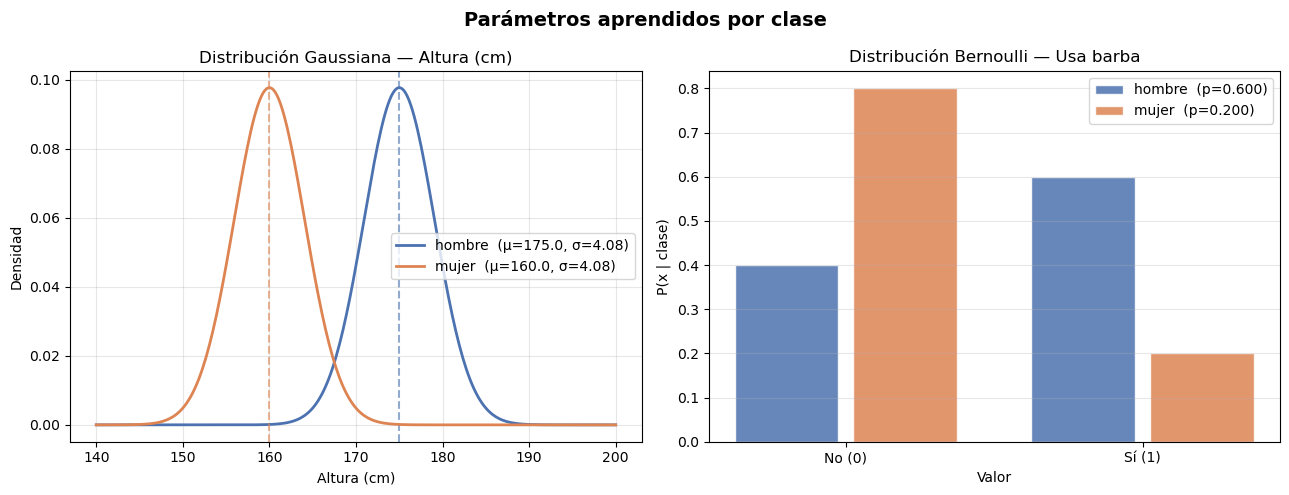

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Parámetros aprendidos por clase", fontsize=14, fontweight="bold")

colors = {"hombre": "#4C72B0", "mujer": "#DD8452"}

# ── Panel izquierdo: Gaussiana (Altura) ─────────────────────────────────────
ax = axes[0]
x_range = np.linspace(140, 200, 300)

for c in model.classes:
    params = model.parameters[c][0]   # feature 0 = altura (gaussian)
    mu, sigma2 = params["mean"], params["var"]
    sigma = np.sqrt(sigma2)
    y_pdf = norm.pdf(x_range, mu, sigma)
    ax.plot(x_range, y_pdf, label=f"{c}  (μ={mu:.1f}, σ={sigma:.2f})", color=colors[c], lw=2)
    ax.axvline(mu, color=colors[c], linestyle="--", alpha=0.6)

ax.set_title("Distribución Gaussiana — Altura (cm)")
ax.set_xlabel("Altura (cm)")
ax.set_ylabel("Densidad")
ax.legend()
ax.grid(alpha=0.3)

# ── Panel derecho: Bernoulli (Usa barba) ────────────────────────────────────
ax = axes[1]
x_bern = [0, 1]
width  = 0.35
offsets = [-0.2, 0.2]
labels  = list(colors.keys())

for offset, c in zip(offsets, model.classes):
    params = model.parameters[c][1]  # feature 1 = usa_barba (bernoulli)
    p = params["p"]
    probs = [1 - p, p]
    ax.bar([xb + offset for xb in x_bern], probs, width=width,
           label=f"{c}  (p={p:.3f})", color=colors[c], alpha=0.85, edgecolor="white")

ax.set_title("Distribución Bernoulli — Usa barba")
ax.set_xlabel("Valor")
ax.set_ylabel("P(x | clase)")
ax.set_xticks([0, 1])
ax.set_xticklabels(["No (0)", "Sí (1)"])
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


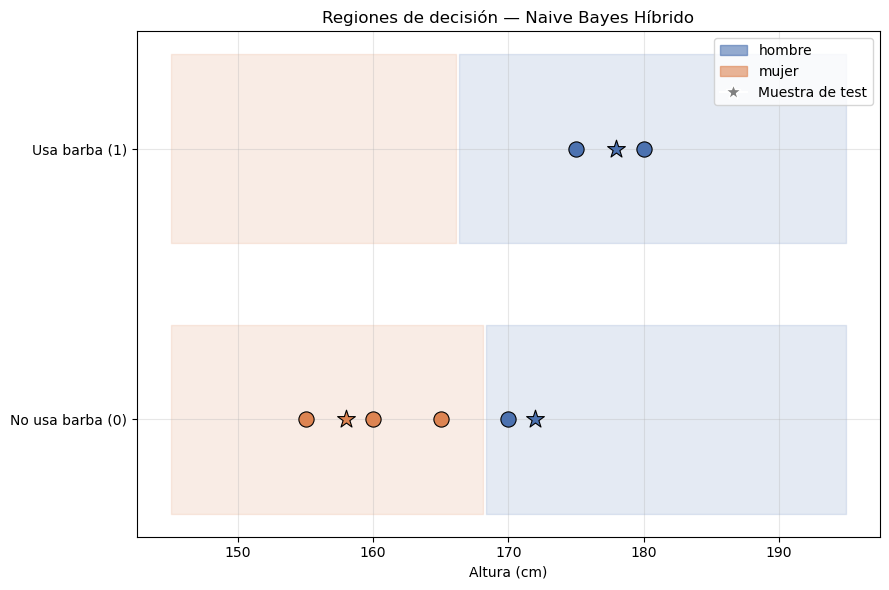

In [7]:
# ── Mapa de probabilidades en el espacio de features ────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

h_grid = np.linspace(145, 195, 200)
b_vals = [0, 1]

# Fondo de colores según predicción
H_mesh, B_mesh = np.meshgrid(h_grid, b_vals)
grid_points = np.column_stack([H_mesh.ravel(), B_mesh.ravel()])
proba_grid  = model.predict_proba(grid_points)

clases_list = list(model.classes)
idx_hombre  = clases_list.index("hombre")
p_hombre    = proba_grid[:, idx_hombre].reshape(H_mesh.shape)

# Graficar banda de decisión
for bi, bv in enumerate(b_vals):
    ax.fill_between(h_grid, bv - 0.35, bv + 0.35,
                    where=(p_hombre[bi] > 0.5),
                    color="#4C72B0", alpha=0.15)
    ax.fill_between(h_grid, bv - 0.35, bv + 0.35,
                    where=(p_hombre[bi] <= 0.5),
                    color="#DD8452", alpha=0.15)

# Puntos de entrenamiento
for xi, yi in zip(X_train, y_train):
    ax.scatter(xi[0], xi[1],
               color=colors[yi], s=120, zorder=5,
               edgecolors="black", linewidths=0.8)

# Puntos de test
for xi, pred in zip(X_test, predicciones):
    ax.scatter(xi[0], xi[1],
               color=colors[pred], s=180, marker="*", zorder=6,
               edgecolors="black", linewidths=0.8)

ax.set_yticks([0, 1])
ax.set_yticklabels(["No usa barba (0)", "Usa barba (1)"])
ax.set_xlabel("Altura (cm)")
ax.set_title("Regiones de decisión — Naive Bayes Híbrido")
ax.grid(alpha=0.3)

patches = [mpatches.Patch(color=colors[c], alpha=0.6, label=c) for c in colors]
star    = plt.Line2D([0], [0], marker="*", color="w", markerfacecolor="gray",
                     markersize=12, label="Muestra de test")
ax.legend(handles=patches + [star])

plt.tight_layout()
plt.show()


## 7. Conclusiones

### Decisiones de diseño

**Detección automática del tipo de feature**  
En lugar de requerir que el usuario especifique el tipo de cada variable, el modelo inspecciona los valores únicos de cada columna. Si el conjunto de valores es un subconjunto de $\{0, 1\}$, se clasifica como Bernoulli; en caso contrario, como Gaussiana. Esto simplifica la interfaz y reduce la posibilidad de errores del usuario.

**Suavizado de Laplace**  
Sin este ajuste, si ninguna muestra de la clase $C$ tiene $x_i = 1$, entonces $P(x_i = 1 \mid C) = 0$ y todo el producto posterior colapsa a cero, independientemente de las demás features. El suavizado agrega pseudoconteos que garantizan $0 < \hat{p}_C < 1$.

**Trabajo en log-espacio**  
El producto de muchas probabilidades pequeñas puede generar *underflow* numérico en punto flotante de 64 bits. Al convertir multiplicaciones en sumas logarítmicas, el cálculo es estable para cualquier dimensionalidad.

**Normalización con log-sum-exp**  
`predict_proba` implementa correctamente la softmax en espacio logarítmico, garantizando que las probabilidades sean no negativas y sumen exactamente 1 por muestra.

### Limitaciones

- La suposición de independencia condicional raramente se cumple en la práctica (features correlacionadas).
- La distribución Gaussiana puede ser una mala aproximación para features asimétricas o multimodales.
- El modelo no contempla features categóricas no binarias (Multinomial Naive Bayes).


# !Muchas gracias!